In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from made.can import CAN

sys.path.insert(0, os.path.abspath("../../.."))
from spatial_nav.CAN_IMP import torus3D_manifold, visualize3D
from spatial_nav.CAN_IMP.CAN3D import CAN3D

## 3-Dimensional Torus (T^3)
Since it is hard to visualize a 3D torus (it would need 4D) because a 3D scatter plot would cause outer neurons to block the view of inner neurons. Our approach is therefore to slice the 3D volumes into 2D slices. This means comparing two axes, for example theta_1 and theta_2 while fixing theta_3.

First, we create a manifold and visualize the distance metric over it. This is the distance between two points on the manifold amd it should show gradually increasing distance and be periodic.

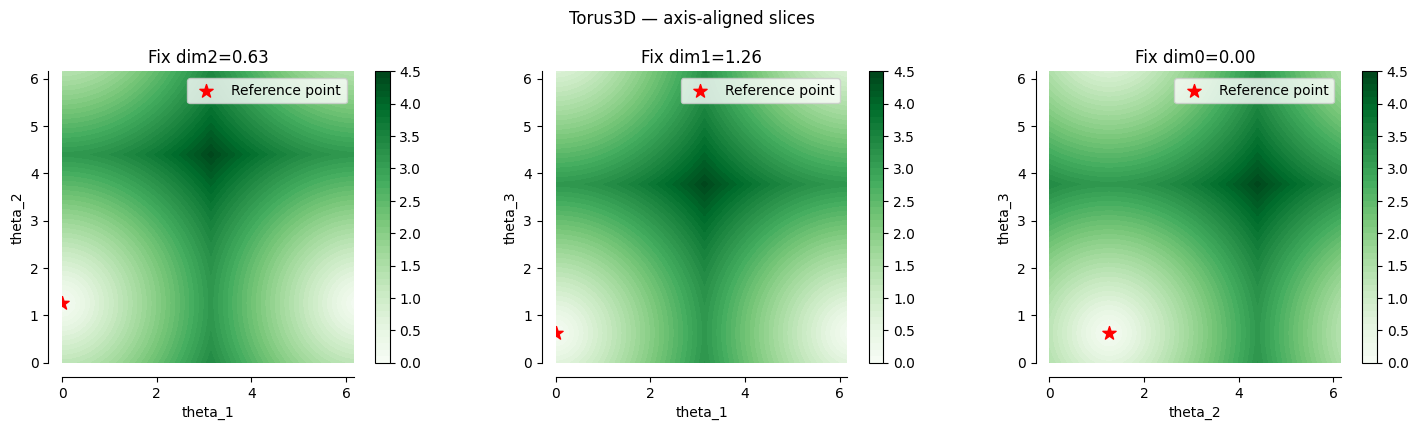

In [2]:
m = torus3D_manifold.Torus3D()

# sample points
points = m.parameter_space.sample(10)
#pick a random point from the torus
idx = np.random.randint(0, points.shape[0])
sample = points[idx, :]
assert m.contains(sample), "Sample point is not in the manifold"

fig, axes = visualize3D._visualize_manifold_3d(m, show_distances=True, distance_point=sample)

## CAN
Create the 3D CAN, activate a random neuron and visualize how this neuron exites the other neurons in the population. Showing if the connectivity matrix of each 4 randomly picked neurons is correct. 

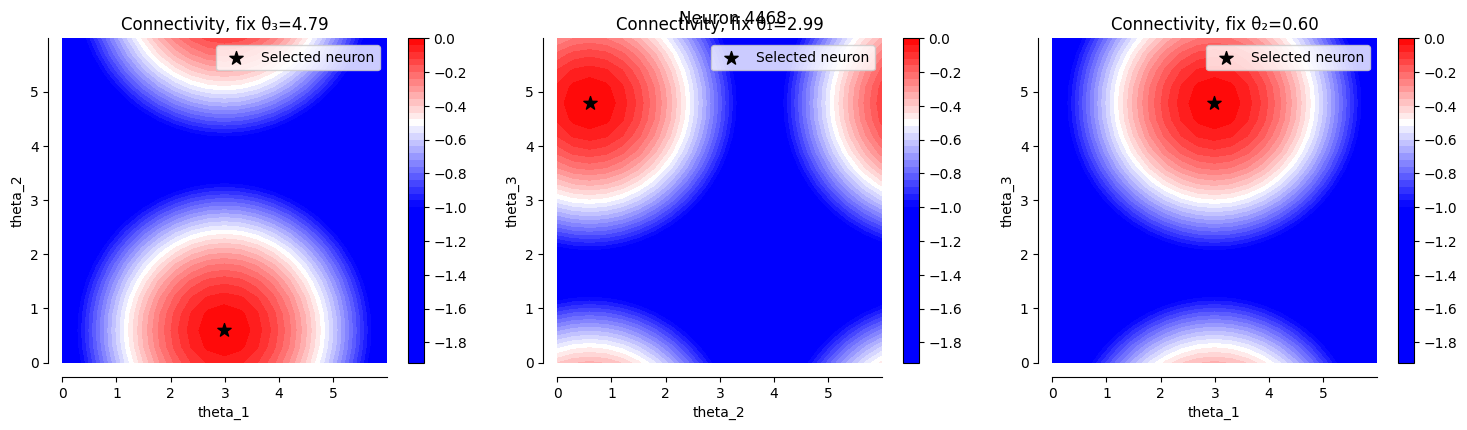

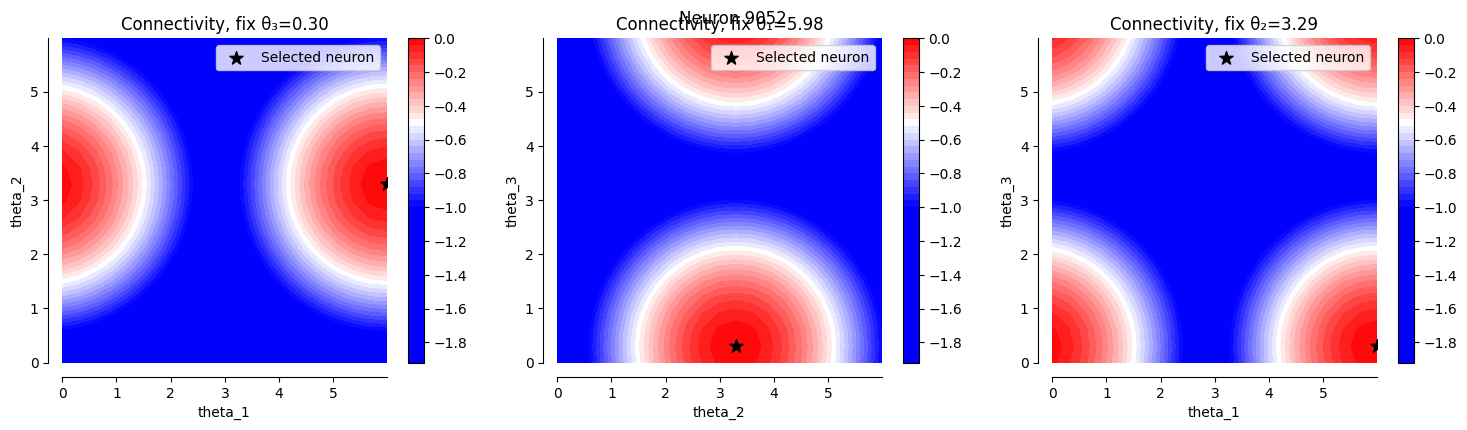

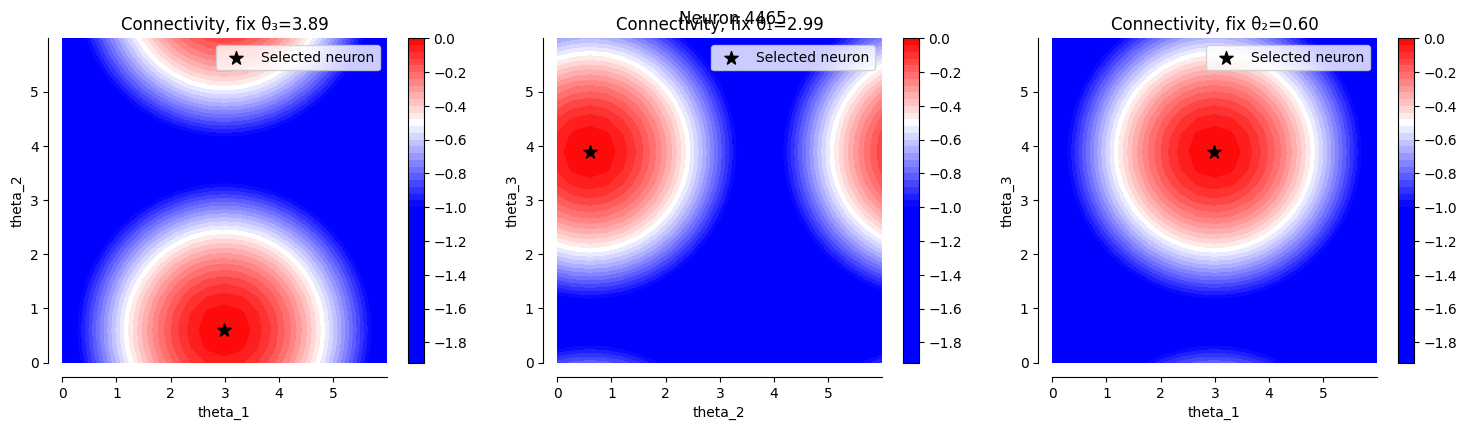

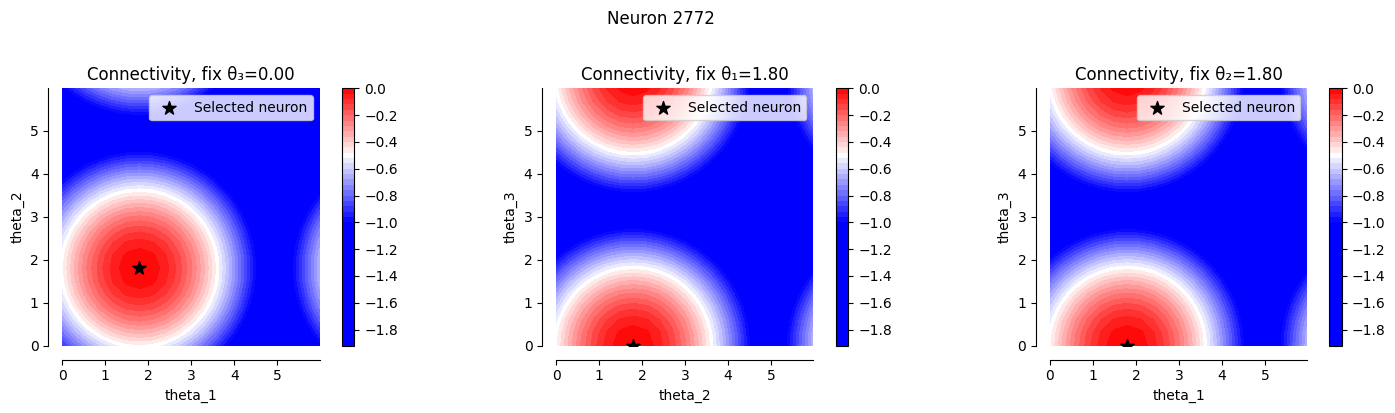

In [3]:
spacing = 0.3  # Adjust this: smaller = more neurons, but heavier memory
can_3d = CAN3D(m, spacing=spacing, alpha=3.0, sigma=3.0)
results = visualize3D.visualize_can_connectivity_3d(can_3d)
plt.show()

## Plot a CAN state
Show the acitivty levels of an randomly picked point and the activity levels of the neurons within a radius of that point. Checking two things, first, can we create a localised bump in a spesific random location. Secondly, will this broad bump converge into a smaller stable attractor state.

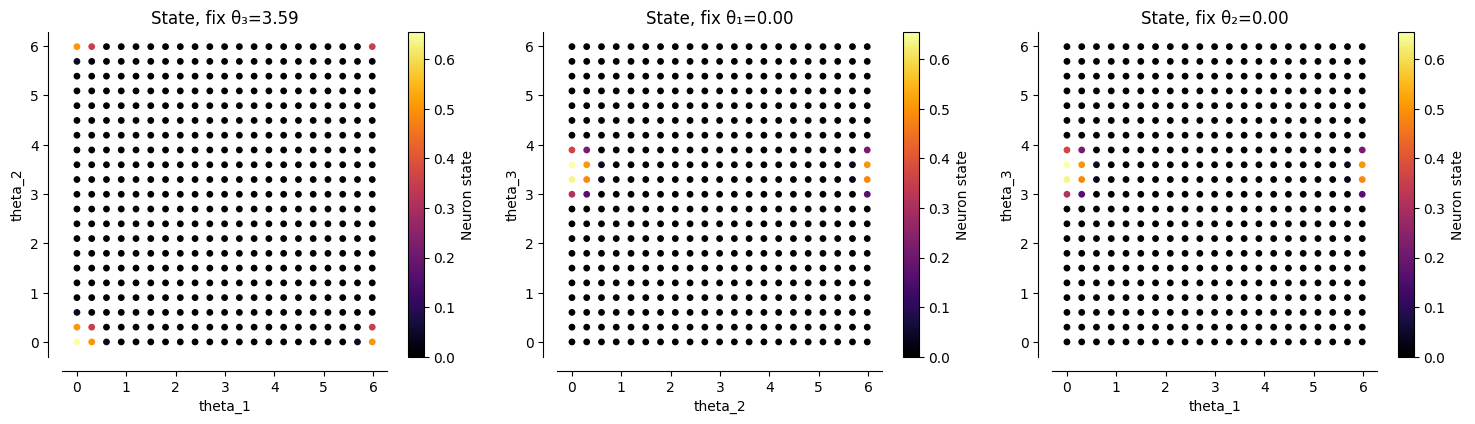

In [4]:
#Sample random coordinate
sample_coords = can_3d.manifold.parameter_space.sample(100)[np.random.randint(0, 99), :]
assert can_3d.manifold.contains(sample_coords), "Sample coordinates not in manifold"

#Reset activity at random coordinate
can_3d.reset(mode="point", point=np.array(sample_coords), radius=0.3)

#Let CAN run to see if activity stabilize
for i in range(50):
    can_3d()

fig, axes = visualize3D.visualize_can_state_3d(can_3d)
plt.show()
